# LLM prompting fundamentals: 

In the past few years language model have improved drastically. Indeed, language model can now write you syntactically perfect Python in the blink of and eye. That is no longer the difficult part (learning basic coding).

The hard part is that **the model cannot know about your problem context or your dataset.** 

It does not know the specific context of your project, the meaning of your data, or the constraints and limitations that shape your problem.

It will nevertheless produce confident, well-formatted, plausible-looking code built entirely on assumptions it invented based on what you provided.

**Core Idea : an LLM is highly capable but context dependent. These models are trained to always produce a plausible answer rather than admit uncertainty. So every fact you leave out of your prompt might lead the model to guess and provide the statistically most common fact from its training data. Sometimes that guess crashes. Other times it does not which is why it has to be used cautiously.**

### What you will do

You will prompt a model on the *same dataset* three times, changing **nothing but the prompt**.

| Round | Prompt | What comes back | How it fails |
|---|---|---|---|
| **1** | One lazy sentence | Code for a *different dataset* that the model invented | **Loudly**, it crashes or is out of context |
| **2** | Correct schema, nothing else | Careful code that passes every check you know | **Silently**, a plausible but wrong result |
| **3** | Full specification | Honest evaluation, an unflattering number, a defensible claim | It does not |


### How to use this notebook

Keep a chat window open next to it. Any model will do the trick (Claude, ChatGPT, Gemini). 

For each round:

1. Copy the suggested printed prompt
2. Run the prompt cell into your chat
3. Copy the code that comes back into the empty cell → **run it**

Your model will not answer exactly like mine. That is fine, and it is part of the lesson. Each round therefore gives you:

- a **"what to expect and why"** section *before* you run it. Read it first, then check whether your model behaved as predicted
- a **symptom checklist** to diagnose whatever your model actually produced
- a **reference cell** reproducing the typical answer, so the notebook works end-to-end even if your model surprises you

---
## Setup
Importing essential libraries

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)

RANDOM_SEED = 42
TARGET_ALIAS = "outcome_value"
pd.set_option("display.width", 120)

python       3.14.3
numpy        2.5.1
pandas       3.0.5
matplotlib   3.11.1
scikit-learn 1.9.0


---

## The dataset: Oxford Parkinson's Disease Telemonitoring

[**UCI Machine Learning Repository, dataset #189** — Tsanas & Little (2009).](https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring)

The UPDRS (Unified Parkinson's Disease Rating Scale) is a measure of Parkinson's severity. Scoring it requires a neurologist, in a clinic, with the patient physically present. It is slow, expensive, and because it depends on a human rater it is subjective.

However, parkinson's degrades speech very early: the voice becomes breathy, unstable in pitch and amplitude. If a cheap acoustic measurement taken from a microphone at home could stand in for a UPDRS score, you could monitor disease progression continuously instead of relying on a specialist to do so.

**The study.** 42 people with early-stage Parkinson's were given a telemonitoring device at home. Each ran a recording **session** roughly weekly for six months. From each recording, 16 acoustic dysphonia measures were extracted :
- jitter = cycle-to-cycle variation in pitch
- shimmer = variation in amplitude
- NHR/HNR = noise-to-harmonics ratios
- RPDE, DFA, PPE = nonlinear signal-dynamics measures

## The task :

**Predict `total_UPDRS`** from the 16 voice measures using machine learning.


### Data inspection
Let's load the dataset first and inspect it to have a better first feeling of what it contains.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

# ═══════════════════════════════════════════════════════════════════
# 1.  FETCH — the real dataset from the UCI repository
# ═══════════════════════════════════════════════════════════════════

UCI_ID = 189
UCI_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "parkinsons/telemonitoring/parkinsons_updrs.data"
)
CACHE = Path("parkinsons_updrs.csv")

# Everything that is NOT a dysphonia measure: identifiers, covariates, targets.
NON_VOICE = ["subject#", "age", "sex", "test_time", "motor_UPDRS", "total_UPDRS"]


def load_telemonitoring(cache: str | Path = CACHE) -> pd.DataFrame:
    """Load the UCI Parkinson's Telemonitoring dataset, with fallbacks.

    Tries, in order: a local cached CSV, the `ucimlrepo` package, then the
    UCI archive URL. Caches to disk so the notebook runs offline afterwards.
    """
    cache = Path(cache)
    if cache.exists():
        return pd.read_csv(cache)

    try:  # official UCI python package
        from ucimlrepo import fetch_ucirepo

        data = fetch_ucirepo(id=UCI_ID).data
        frame = (
            data.original
            if data.original is not None
            else pd.concat([data.features, data.targets], axis=1)
        )
        frame.to_csv(cache, index=False)
        return frame
    except Exception as err:
        print(f"ucimlrepo unavailable ({type(err).__name__}), trying direct download…")

    frame = pd.read_csv(UCI_URL)
    frame.to_csv(cache, index=False)
    return frame


def fetch_parkinson_telemonitoring(
    cache: str | Path = CACHE,
    drop_motor_updrs: bool = True,
) -> tuple[pd.DataFrame, dict]:
    """
    Load UCI #189 and describe its structure for `disguise_dataset`.

    Parameters
    ----------
    cache            : path of the cached CSV
    drop_motor_updrs : drop 'motor_UPDRS'.  It is a near-duplicate of the
                       target (r ≈ 0.95) and would hand the answer to any
                       model — a second, much cruder leak that would mask
                       the repeated-measures one we want to teach.

    Returns
    -------
    df   : the raw DataFrame (5875 rows × 21 columns, or 20 without motor)
    meta : dict with 'target', 'group_col', 'sequence_col', 'feature_cols',
           'categorical_cols', 'task', 'description'
    """
    df = load_telemonitoring(cache)

    if drop_motor_updrs and "motor_UPDRS" in df.columns:
        df = df.drop(columns=["motor_UPDRS"])

    # The 16 acoustic dysphonia measures: the only legitimate predictors.
    voice = [c for c in df.columns if c not in NON_VOICE]

    df["subject#"] = df["subject#"].astype(int)
    df["sex"] = df["sex"].astype(int)

    n_subjects = df["subject#"].nunique()
    reps = df.groupby("subject#").size()

    meta = {
        "target": "total_UPDRS",
        "group_col": "subject#",
        "sequence_col": "test_time",
        "feature_cols": voice + ["age", "sex"],
        "voice_cols": voice,
        "categorical_cols": ["sex"],
        "n_subjects": int(n_subjects),
        "description": (
            f"UCI #189: {n_subjects} patients, {int(reps.min())}-{int(reps.max())} "
            f"voice recordings each ({len(df)} rows). UPDRS moves slowly within a "
            f"patient, so a naive random split puts near-duplicate rows of the same "
            f"patient on both sides and leaks badly."
        ),
    }
    return df, meta

In [3]:
# ── Fetch the REAL table: real column names, real values ──
df_raw, meta = fetch_parkinson_telemonitoring()
          # alias kept for the later rounds of the notebook

print("=" * 65)
print("  1. FETCHING RAW DATASET")
print("=" * 65)
print(f"  Shape       : {df_raw.shape}")
print(f"  Target      : {meta['target']}")
print(f"  Group col   : {meta['group_col']}")
print(f"  Subjects    : {meta['n_subjects']}")
print(f"  Voice cols  : {meta['voice_cols']}")
print(f"  Description : {meta['description']}")
print()
df_raw.head()

  1. FETCHING RAW DATASET
  Shape       : (5875, 21)
  Target      : total_UPDRS
  Group col   : subject#
  Subjects    : 42
  Voice cols  : ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
  Description : UCI #189: 42 patients, 101-168 voice recordings each (5875 rows). UPDRS moves slowly within a patient, so a naive random split puts near-duplicate rows of the same patient on both sides and leaks badly.



,subject#,age,sex,test_time,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [4]:
# ── Fetch the REAL table: real column names, real values ──
df_raw, meta = fetch_parkinson_telemonitoring()
          # alias kept for the later rounds of the notebook

print("=" * 65)
print("  1. FETCHING RAW DATASET")
print("=" * 65)
print(f"  Shape       : {df_raw.shape}")
print(f"  Target      : {meta['target']}")
print(f"  Group col   : {meta['group_col']}")
print(f"  Subjects    : {meta['n_subjects']}")
print(f"  Voice cols  : {meta['voice_cols']}")
print(f"  Description : {meta['description']}")
print()
df_raw.head()

  1. FETCHING RAW DATASET
  Shape       : (5875, 21)
  Target      : total_UPDRS
  Group col   : subject#
  Subjects    : 42
  Voice cols  : ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
  Description : UCI #189: 42 patients, 101-168 voice recordings each (5875 rows). UPDRS moves slowly within a patient, so a naive random split puts near-duplicate rows of the same patient on both sides and leaks badly.



,subject#,age,sex,test_time,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


### Disguising the dataset and why we need to do so.

UCI #189 has been public since 2009. It is on Kaggle, in tutorials, in blog posts, in
textbook chapters, and — importantly — in the training data of every model you are about
to talk to. **Paste `df.head()` of the raw file into a chat window and you are no longer
testing whether the model can reason about *your* data.** You are testing whether it
recognises a table it has already read a thousand times. It can complete the column names
from memory, quote the published R², and even recite the repeated-measures caveat —
without ever looking at what you sent. That would make every round below meaningless.

So we hand the model a table it cannot recognise. `disguise_dataset()`:

- **renames every column** to an anonymous `feature_i`, handed out in shuffled order, so the
  index carries no information about the original position;
- **rescales the target** (affine only — regression quality is untouched) and renames it
  `outcome_value`;
- **adds 2 % gaussian noise** to the numeric features, so no cell value matches the published
  file byte-for-byte;
- **injects a few pure-noise decoy columns**, so even the shape stops matching;
- **remaps the subject IDs** to opaque, non-consecutive codes and shuffles the rows.

None of this changes what the data *means*. The correlations, the variance structure and the
repeated-measures trap all survive — that is the whole point. Only the fingerprint is gone.

**We keep the key.** From here on, every figure and every printout is computed on the
disguised table and labelled `feature_10 (Jitter(%))`: the name *the model* sees first, the
real variable in parentheses so the section stays readable for *you*. The key stays in this
notebook and never goes into a prompt.


In [5]:
def _build_card(
    out: pd.DataFrame,
    fake_target: str,
    new_group: str,
    new_seq: str | None,
) -> str:
    """Documentation the student/LLM is allowed to see — no origin, no key."""

    is_classification = not np.issubdtype(out[fake_target].dtype, np.floating)
    task_name = "Binary classification" if is_classification else "Regression"
    target_kind = "categorical" if is_classification else "continuous, numeric"

    card = "DATASET CARD\n"
    card += "=" * 65 + "\n\n"
    card += f"Task           : {task_name}\n"
    card += f"Target column  : '{fake_target}'  ({target_kind})\n"
    card += f"Rows           : {out.shape[0]}\n"
    card += f"Columns        : {out.shape[1]}\n"
    n_missing = int(out.isna().sum().sum())
    card += f"Missing values : {n_missing} cells\n\n"

    if is_classification:
        counts = out[fake_target].value_counts().sort_index()
        card += "CLASS BALANCE\n"
        card += "-" * 65 + "\n"
        for lbl, n in counts.items():
            card += f"  class {lbl} : {n} rows ({n / len(out):.1%})\n"
        card += "\n"

    card += "⚠️  REPEATED MEASURES — CRITICAL\n"
    card += "-" * 65 + "\n"
    card += f"Column '{new_group}' is a subject/instance identifier.\n"
    n_unique = int(out[new_group].nunique())
    reps = out.groupby(new_group).size()
    card += f"There are {n_unique} unique subjects, each appearing "
    card += f"{int(reps.min())}-{int(reps.max())} times.\n"

    splitters = (
        "GroupShuffleSplit, StratifiedGroupKFold"
        if is_classification
        else "GroupShuffleSplit, GroupKFold"
    )

    card += "You MUST group by this column when splitting train/test\n"
    card += f"(e.g. {splitters}) to avoid data leakage.\n"
    card += "Do NOT use a naive random train_test_split.\n\n"

    if new_seq:
        card += f"Column '{new_seq}' is a within-subject sequence index.\n"
        card += "It should generally NOT be used as a predictive feature.\n\n"

    card += "COLUMN DETAILS\n"
    card += "-" * 65 + "\n"
    for c in out.columns:
        tag = ""
        if c == fake_target:
            tag = " ← TARGET"
        elif c == new_group:
            tag = " ← SUBJECT ID (group)"
        elif c == new_seq:
            tag = " ← SEQUENCE INDEX"

        dtype = str(out[c].dtype)
        if np.issubdtype(out[c].dtype, np.number):
            mn, mx = out[c].min(), out[c].max()
            card += f"  {c:28s}  {dtype:8s}  [{mn:.4f} .. {mx:.4f}]{tag}\n"
        else:
            card += f"  {c:28s}  {dtype:8s}{tag}\n"

    card += "\nSAMPLE ROWS (first 5)\n"
    card += "-" * 65 + "\n"
    with pd.option_context("display.max_columns", 30, "display.width", 120):
        card += out.head(5).to_string() + "\n"

    return card


def disguise_dataset(
    df: pd.DataFrame,
    target_col_name: str,
    group_col: str,
    sequence_col: str | None = None,
    categorical_cols: list[str] | None = None,
    noise_frac: float = 0.0,
    n_decoys: tuple[int, int] = (3, 6),
):
    """
    Rename columns, transform distributions, inject noise, and shuffle.

    Adjusted from the synthetic-data version to cope with a real dataset:
      * the group column may hold strings, and its value can itself leak
        the label — it is always remapped to opaque codes.
      * low-cardinality columns (e.g. `sex`) are recoded, not log-scaled.
      * `drop_feature_frac` / `noise_frac` break the dataset's fingerprint,
        so the shape and the exact cell values no longer match the
        published file.  Both preserve the predictive signal.

    Parameters
    ----------
    df                : raw DataFrame
    target            : name of the target column
    group_col         : name of the subject/instance identifier
    sequence_col      : name of the within-subject sequence column, or None
    categorical_cols  : columns to recode rather than rescale
    drop_feature_frac : fraction of feature columns to drop (0-0.5)
    noise_frac        : gaussian noise added to numeric features, as a
                        fraction of each column's std (e.g. 0.02)
    n_decoys          : (min, max) number of pure-noise columns to inject

    Returns
    -------
    disguised_df  : transformed DataFrame
    new_target    : new name of the target column
    new_group_col : new name of the group/subject column
    new_seq_col   : new name of the sequence column (or None)
    dataset_card  : full documentation string
    key           : only if return_key — dict with the column/label mapping
    """

    rng = np.random.default_rng(RANDOM_SEED)
    categorical_cols = list(categorical_cols or [])

    if target_col_name not in df.columns:
        raise KeyError(f"target_col_name {target_col_name!r} is not a column of df")

    # ── Name pool: plain feature_i names, handed out in random order ──
    # Every non-target column (real or decoy) gets one.  Because the pool is
    # shuffled, the index carries no information about the original position.
    n_decoy = int(rng.integers(*n_decoys))
    n_features = len(df.columns) - 1 + n_decoy
    pool = [f"feature_{i}" for i in range(1, n_features + 1)]
    rng.shuffle(pool)

    fake_target = TARGET_ALIAS

    # ── Build column mapping ────────────────────────────────────
    col_map = {}
    pool_idx = 0
    new_group = None
    new_seq = None

    for c in df.columns:
        if c == target_col_name:
            col_map[c] = fake_target
        else:
            col_map[c] = pool[pool_idx]
            pool_idx += 1
            if c == group_col:
                new_group = col_map[c]
            elif c == sequence_col:
                new_seq = col_map[c]

    if new_group is None:
        raise KeyError(f"group_col {group_col!r} is not a column of df")

    out = df.rename(columns=col_map).copy()
    new_categorical = [col_map[c] for c in categorical_cols if c in col_map]

    # ── Target ──────────────────────────────────────────────────
    label_map: dict = {}
    # Affine only — preserve regression quality.
    a, b = rng.uniform(5, 10.0), rng.uniform(100, 1000)
    out[fake_target] = out[fake_target] * a + b

    # ── Group column: always remapped (string IDs can leak the label) ──
    # Each subject gets a distinct integer drawn without replacement from a
    # much larger range, so the codes are opaque and non-consecutive — the
    # original ordering (and any hint of the source file) is gone.
    unique_ids = sorted(out[new_group].dropna().unique().tolist())
    id_pool = max(1000, 20 * len(unique_ids))
    new_ids = rng.choice(id_pool, size=len(unique_ids), replace=False) + 1
    group_map = dict(zip(unique_ids, new_ids.tolist()))
    out[new_group] = out[new_group].map(group_map).astype("int64")

    # ── Transform the remaining columns ─────────────────────────
    for col in out.columns:
        if col in (fake_target, new_group):
            continue

        if col in new_categorical or out[col].nunique(dropna=True) <= 5:
            # Low-cardinality → recode levels, don't rescale.
            levels = sorted(out[col].dropna().unique().tolist())
            recode = dict(zip(levels, rng.permutation(len(levels)) + 1))
            out[col] = out[col].map(recode)
            continue

        if not np.issubdtype(out[col].dtype, np.number):
            continue

        if col == new_seq:
            # Scale sequence to look like a measurement timestamp.
            out[col] = out[col] * rng.uniform(0.5, 3.0) + rng.uniform(10, 100)
            continue

        # Regular features — small noise first (kills exact-value lookup),
        # then a random monotone-ish transform.
        if noise_frac > 0:
            sd = float(out[col].std())
            if np.isfinite(sd) and sd > 0:
                out[col] = out[col] + rng.normal(0, sd * noise_frac, len(out))

        choice = rng.integers(0, 3)
        if choice == 0:
            out[col] = out[col] * rng.uniform(0.3, 5.0) + rng.uniform(-100, 100)
        elif choice == 1:
            shift = abs(out[col].min()) + 1 if out[col].min() <= 0 else 0
            out[col] = np.log1p(out[col] + shift)
        elif choice == 2:
            out[col] = (out[col] - out[col].mean()) / (out[col].std() + 1e-9)

    # ── Inject decoy columns ────────────────────────────────────
    decoy_names = []
    for _ in range(n_decoy):
        name = pool[pool_idx]
        pool_idx += 1
        kind = rng.integers(0, 3)
        if kind == 0:
            out[name] = rng.normal(0, 1, len(out))
        elif kind == 1:
            out[name] = rng.exponential(2, len(out))
        else:
            out[name] = rng.uniform(-5, 5, len(out))
        decoy_names.append(name)

    # ── Shuffle rows, lay the columns out in feature order ──────
    out = out.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    features = sorted(
        (c for c in out.columns if c != fake_target),
        key=lambda c: int(c.rsplit("_", 1)[1]),
    )
    out = out[features + [fake_target]]  # target last

    card = _build_card(out, fake_target, new_group, new_seq)

    key = {
        "col_map": col_map,
        "label_map": label_map,
        "group_map": group_map,
        "decoy_columns": decoy_names,
        "target": fake_target,
        "group_col": new_group,
        "sequence_col": new_seq,
    }
    return out, fake_target, new_group, new_seq, card, key

In [6]:
df, new_target, new_group, new_seq, card, key = disguise_dataset(
    df_raw,
    target_col_name=meta["target"],
    group_col=meta["group_col"],
    sequence_col=meta["sequence_col"],
    categorical_cols=meta["categorical_cols"],
    noise_frac=0.02,
)

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,outcome_value
0,-85.124159,0.445370,69.499247,-16.515741,0.135758,0.581187,0.018143,-28.675527,0.255657,0.086176,...,0.453587,4.207173,44,1.047153,1,215.492833,0.019522,-2.368547,0.404059,896.097600
1,-85.141725,2.378286,69.470883,-16.799745,0.209541,-0.566672,0.005832,-28.675580,-0.154570,0.069037,...,0.529157,3.620149,681,-0.327235,2,220.644034,0.011533,-1.045072,0.427314,608.985304
2,-85.119216,0.237523,69.855221,-15.935066,0.211345,0.928524,0.015165,-28.675530,0.422327,0.086125,...,-0.735258,4.074582,739,0.699851,1,93.333725,0.031084,-0.675800,0.399218,627.659497
3,-85.110364,-3.090320,69.946457,-15.712770,0.296369,1.518185,0.010115,-28.675526,0.190117,0.084130,...,-1.693516,4.114014,735,0.128061,1,121.112870,0.045731,0.861821,0.579157,649.605547
4,-85.081612,-0.888166,69.295560,-14.456000,0.380700,3.580335,0.049224,-28.675397,4.716117,0.156527,...,-3.640404,4.143980,801,4.415655,2,181.895128,0.070291,0.632124,0.543335,790.714637


In [7]:
# ═══════════════════════════════════════════════════════════════════
# 2.  THE KEY — the only place where the two vocabularies meet
# ═══════════════════════════════════════════════════════════════════
# `key["col_map"]` maps  real name -> disguised name.  For plotting we need the
# reverse direction, so that an axis can read "feature_10 (Jitter(%))": what the
# model would see, with the truth in parentheses.
#
# Everything below is for OUR eyes. None of it is ever pasted into a prompt.

REAL2FAKE: dict[str, str] = key["col_map"]                       # real  -> feature_i
FAKE2REAL: dict[str, str] = {v: k for k, v in REAL2FAKE.items()}  # feature_i -> real
DECOYS: set[str] = set(key["decoy_columns"])


def fake(real_col: str) -> str:
    """Real column name -> the disguised name it now hides behind."""
    return REAL2FAKE[real_col]


def real(fake_col: str) -> str:
    """Disguised name -> real column name ('decoy' if the column was invented)."""
    if fake_col in DECOYS:
        return "decoy"
    return FAKE2REAL.get(fake_col, fake_col)


def lab(fake_col: str) -> str:
    """Axis / print label: 'feature_10 (Jitter(%))'."""
    return f"{fake_col} ({real(fake_col)})"


# The 16 acoustic dysphonia measures, written in the vocabulary the model sees.
# This is the only legitimate predictor set: no target, no identifier, no
# timestamp, and none of the invented decoy columns.
VOICE: list[str] = [fake(c) for c in meta["voice_cols"]]

# The disguise rescaled the target affinely (outcome_value = a * total_UPDRS + b),
# so any error expressed in `outcome_value` units converts back to real UPDRS
# points by one factor. R² is scale-free and needs no conversion.
UPDRS_PER_UNIT: float = df_raw["total_UPDRS"].std() / df[new_target].std()

ROLES = {new_target: "← target", new_group: "← subject id (group)", new_seq: "← sequence index"}

print(f"{'WHAT THE MODEL SEES':<22}{'WHAT IT REALLY IS':<18}ROLE")
print("-" * 65)
for c in df.columns:
    role = ROLES.get(c, "← decoy (pure noise)" if c in DECOYS else "")
    print(f"{c:<22}{real(c):<18}{role}")

print()
print(f"{df.shape[0]} rows x {df.shape[1]} columns "
      f"({len(DECOYS)} of them invented), {df[new_group].nunique()} subjects")
print(f"VOICE = the {len(VOICE)} acoustic measures, disguised: {VOICE[:3]} ...")
print(f"1 unit of {new_target} = {UPDRS_PER_UNIT:.3f} real UPDRS points")

WHAT THE MODEL SEES   WHAT IT REALLY IS ROLE
-----------------------------------------------------------------
feature_1             Shimmer:APQ3      
feature_2             decoy             ← decoy (pure noise)
feature_3             DFA               
feature_4             Shimmer(dB)       
feature_5             PPE               
feature_6             Shimmer:DDA       
feature_7             Jitter:DDP        
feature_8             Jitter(Abs)       
feature_9             Jitter:PPQ5       
feature_10            Jitter(%)         
feature_11            Shimmer           
feature_12            NHR               
feature_13            Shimmer:APQ11     
feature_14            decoy             ← decoy (pure noise)
feature_15            HNR               
feature_16            age               
feature_17            subject#          ← subject id (group)
feature_18            Jitter:RAP        
feature_19            sex               
feature_20            test_time         ← sequence

### A first look at the disguised dataset

Before any modelling, look at the data. Below are the three figures almost anyone would produce
on a new table — distributions, a scatter-matrix, a correlation heatmap. They are drawn from
`df`, exactly the columns a model would receive, each labelled with its real identity in
parentheses so you can follow along.

Read them carefully, because the point of this subsection is uncomfortable: **all three look
completely normal, and all three hide the thing that matters.**

## Distribution of features 

**The vocabulary, if these are new to you:**
- **jitter** — how much the pitch wobbles from one vocal-fold cycle to the next
- **shimmer** — the same idea for loudness
- **HNR / NHR** — how much of the sound is clean tone versus breathy noise (HNR high = clearer voice)
- **RPDE, DFA, PPE** — nonlinear summaries of how (ir)regular the signal is


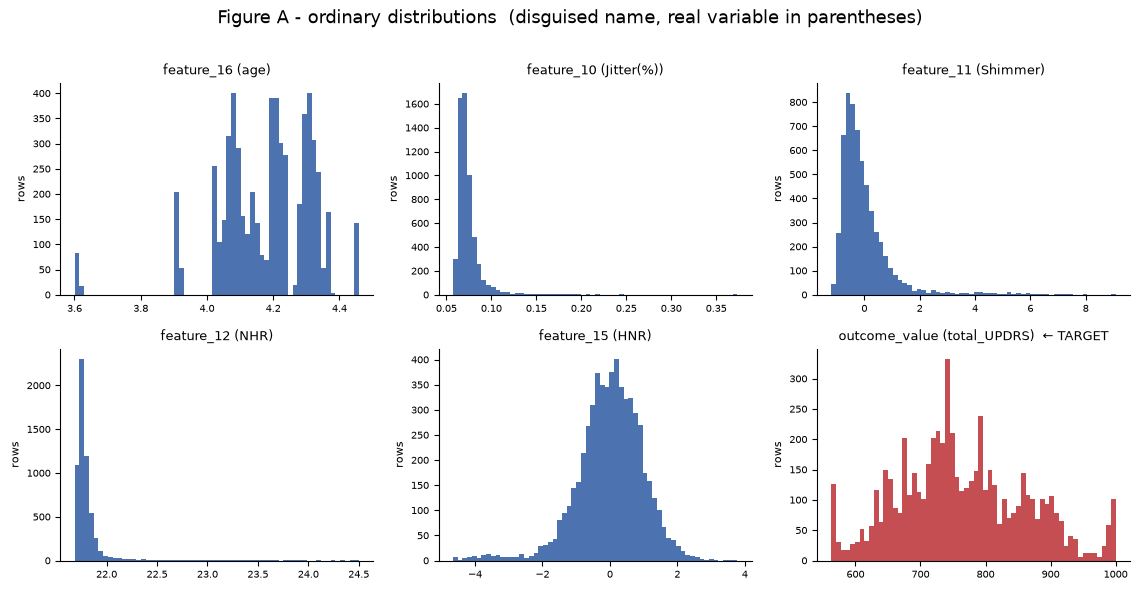

feature_16   (age)          : 5875 distinct values for 5875 rows
outcome_value (total_UPDRS)  : 563 .. 1000 (real scale: 7.0 .. 55.0 points)


In [8]:
# --- Figure A: the six distributions anyone would plot first ---
# Disguised columns; the real variable is named in each panel title.
SHOW = ["age", "Jitter(%)", "Shimmer", "NHR", "HNR"]

fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.8))
for ax, real_col in zip(axes.flat, SHOW):
    col = fake(real_col)
    ax.hist(df[col], bins=60, color="#4C72B0")
    ax.set_title(lab(col), fontsize=9)
    ax.set_ylabel("rows", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

ax = axes.flat[5]
ax.hist(df[new_target], bins=60, color="#C44E52")
ax.set_title(f"{lab(new_target)}  ← TARGET", fontsize=9)
ax.set_ylabel("rows", fontsize=8)
ax.tick_params(labelsize=7)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure A - ordinary distributions  (disguised name, real variable in parentheses)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"{fake('age'):<12} (age)          : {df[fake('age')].nunique()} distinct values "
      f"for {len(df)} rows")
print(f"{new_target:<12} (total_UPDRS)  : "
      f"{df[new_target].min():.0f} .. {df[new_target].max():.0f} "
      f"(real scale: {df_raw['total_UPDRS'].min():.1f} .. {df_raw['total_UPDRS'].max():.1f} points)")


## Scatter matrix

**How to read a scatter-matrix.** Pick any off-diagonal panel: it plots the row variable (y)
against the column variable (x). A tight diagonal cloud means the two move together; a
shapeless blob means they do not.

**What to look at.**
The **bottom row**, `outcome_value` (`total_UPDRS`) against each voice measure.
  Every panel is a **shapeless vertical band**. There is no visible relationship between any
  single voice measure and disease severity.


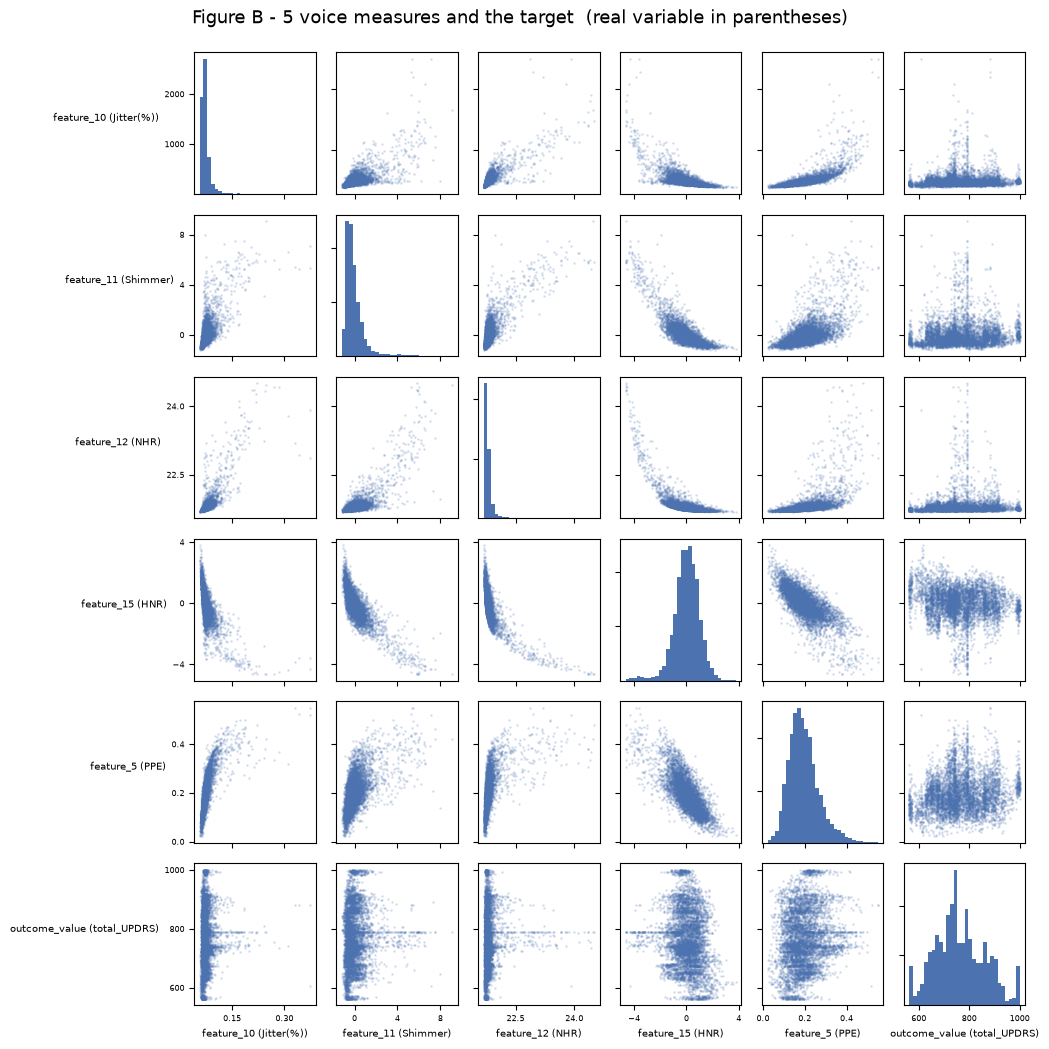

In [ ]:
from matplotlib.ticker import MaxNLocator

SOME = ["Jitter(%)", "Shimmer", "NHR", "HNR", "PPE"]
cols = [fake(c) for c in SOME] + [new_target]

fig, axes = plt.subplots(len(cols), len(cols), figsize=(10.5, 10.5))
for i, row_col in enumerate(cols):
    for j, col_col in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(df[row_col], bins=30, color="#4C72B0")
        else:
            ax.plot(df[col_col], df[row_col], ".", ms=2,
                    alpha=0.15, color="#4C72B0")

        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(labelsize=6)
        if i == len(cols) - 1:
            ax.set_xlabel(lab(col_col), fontsize=7)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(lab(row_col), fontsize=7, rotation=0, ha="right")
        else:
            ax.set_yticklabels([])

fig.suptitle("5 voice measures and the target  (real variable in parentheses)",
             y=0.995, fontsize=13)
plt.tight_layout()
plt.show()

## Correlation heatmap

**What to look at.** A large mass of dark red in the middle of the matrix — but a *scattered*
one. In the published file the five `Jitter` columns sit side by side and the six `Shimmer`
columns likewise, so the redundancy shows up as two clean blocks. The disguise shuffled the
column order, so the same near-duplicates are now spread all over the matrix. The printout under
the figure picks two of them out: `feature_7` / `feature_18` (`Jitter:DDP` and `Jitter:RAP`) and
`feature_6` / `feature_1` (`Shimmer:DDA` and `Shimmer:APQ3`) both come out at r ≈ 0.999. In the
raw file those pairs are **exactly 1.000** — `Jitter:DDP` is by definition three times
`Jitter:RAP`, `Shimmer:DDA` three times `Shimmer:APQ3` — and only the 2 % noise we injected
moves them off 1. They are the same measurement rescaled.

So "16 predictors" is a marketing number. You have perhaps five or six genuinely distinct pieces
of acoustic information — and under `feature_1 … feature_23` there is nothing whatsoever to warn
a model of that.

**Then the last row and column** — the target — is almost white too. The strongest correlation
between any single voice measure and the outcome is about **0.16**, which is very weak.

**The bridge to everything that follows:** nothing in Figures A, B or C is wrong, and nothing in
them warns you about the trap. They are exactly what an LLM would produce if you asked it to
"explore the data", and exactly what it would see if you pasted the result back.

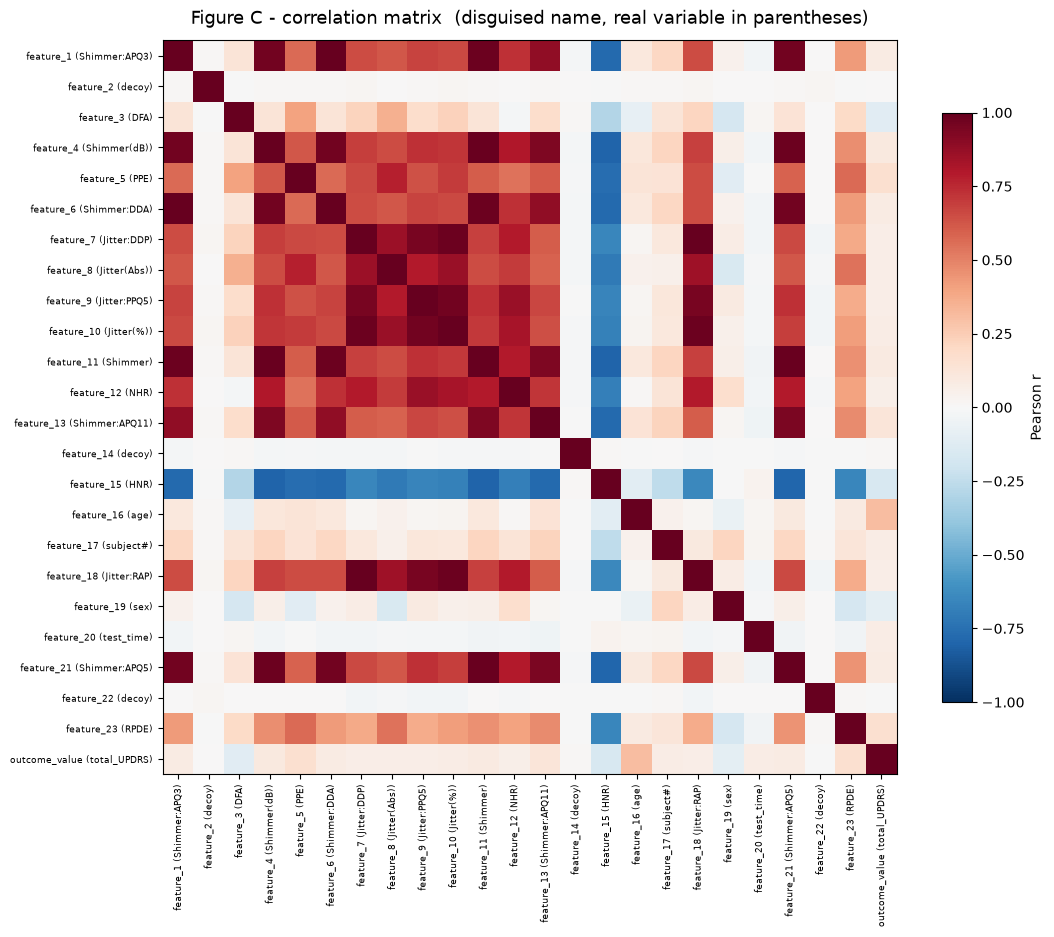

r(feature_7 (Jitter:DDP), feature_18 (Jitter:RAP)) = 0.9993
r(feature_6 (Shimmer:DDA), feature_1 (Shimmer:APQ3)) = 0.9996

Strongest voice measure vs target: feature_15 (HNR)  |r| = 0.162


In [10]:
# --- Figure C: correlation heatmap of the disguised table ---
corr = df.corr(numeric_only=True)
labels = [lab(c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")

ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(labels)), labels, fontsize=6.5)
ax.set_title("Figure C - correlation matrix  (disguised name, real variable in parentheses)",
             fontsize=13, pad=12)
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
plt.tight_layout()
plt.show()

# The redundancy the anonymous names hide, and the strongest link to the target.
pairs = [("Jitter:DDP", "Jitter:RAP"), ("Shimmer:DDA", "Shimmer:APQ3")]
for a, b in pairs:
    r = corr.loc[fake(a), fake(b)]
    print(f"r({lab(fake(a))}, {lab(fake(b))}) = {r:.4f}")

exclude = [new_target, new_group, new_seq, fake("age")]
best = corr[new_target].drop(index=[c for c in exclude if c]).abs().sort_values(ascending=False)
top = best.index[0]
print(f"\nStrongest voice measure vs target: {lab(top)}  |r| = {best.iloc[0]:.3f}")

### Now: the facts the file does **not** contain

Everything above is what an LLM would see if you pasted `df.head()` and `df.dtypes` into a chat — and remember it sees only the left-hand name of each pair, never the parenthesised one. Here is what is *not* in there :

1. **5,875 rows are not 5,875 people. They are 42 people.** Each patient contributed 101–168 recordings, spread over ~24 weekly sessions. So the nesting is two levels deep — *phonations inside sessions inside patients* — and rows from the same patient are heavily correlated.
2. **`subject#` (`feature_17`) is an identifier, not a quantity.** Patient 17 is not "one more than" patient 16. It is stored as `int64`, so every library on earth will happily treat it as a number.
3. ⚧ **`sex` (`feature_19`) is coded `0` = male, `1` = female** in the published file (the disguise recodes the two levels, so even that convention is now arbitrary). Nothing in the file says so. A model may equally well assume the reverse, or treat it as ordinal.
4. ⏱️ **`test_time` (`feature_20`) is in days since recruitment, and some values are negative** (screening sessions before the official start date). The fractional part encodes the time of day. A model told only `float64` may reasonably decide negative values are corrupt and drop them.

Point 1 also settles the *scientific question*, which is the thing that ultimately determines whether an analysis is right or wrong. 

The clinical promise of telemonitoring is: **"hand this device to a patient we have never recorded before, and read off their severity."** That means the model must generalise **to new people** and not to new recordings from people it has already memorised.

Let us confirm point 1 numerically, because it drives everything downstream.

In [11]:
# All of this is computed on the DISGUISED table — the trap survives the disguise.
n_rows, n_subjects = len(df), df[new_group].nunique()
per_subject = df.groupby(new_group).size()

print(f"group column : {lab(new_group)}")
print(f"target       : {lab(new_target)}\n")
print(f"{n_rows} recordings from {n_subjects} subjects")
print(f"recordings per subject: min={per_subject.min()}, "
      f"median={int(per_subject.median())}, max={per_subject.max()}\n")

# How much of the variation in the outcome is 'which patient is this?'
grp = df.groupby(new_group)[new_target]
print(f"SD of {new_target} overall                : {df[new_target].std():.2f} units")
print(f"SD *between* subjects (of subject means)  : {grp.mean().std():.2f} units")
print(f"SD *within* a subject (mean over subjects): {grp.std().mean():.2f} units")

between = (grp.size() * (grp.mean() - df[new_target].mean()) ** 2).sum()
total = ((df[new_target] - df[new_target].mean()) ** 2).sum()
print(f"\n=> {between / total:.0%} of the variance in the outcome is WHO the patient is,")
print("   not how that patient changed over six months.")
print("   (the target is only rescaled, so this ratio is exactly the one of the real")
print(f"    total_UPDRS, whose real spread is {df_raw['total_UPDRS'].std():.2f} UPDRS points)")

group column : feature_17 (subject#)
target       : outcome_value (total_UPDRS)

5875 recordings from 42 subjects
recordings per subject: min=101, median=141, max=168

SD of outcome_value overall                : 97.52 units
SD *between* subjects (of subject means)  : 95.18 units
SD *within* a subject (mean over subjects): 22.90 units

=> 93% of the variance in the outcome is WHO the patient is,
   not how that patient changed over six months.
   (the target is only rescaled, so this ratio is exactly the one of the real
    total_UPDRS, whose real spread is 10.70 UPDRS points)


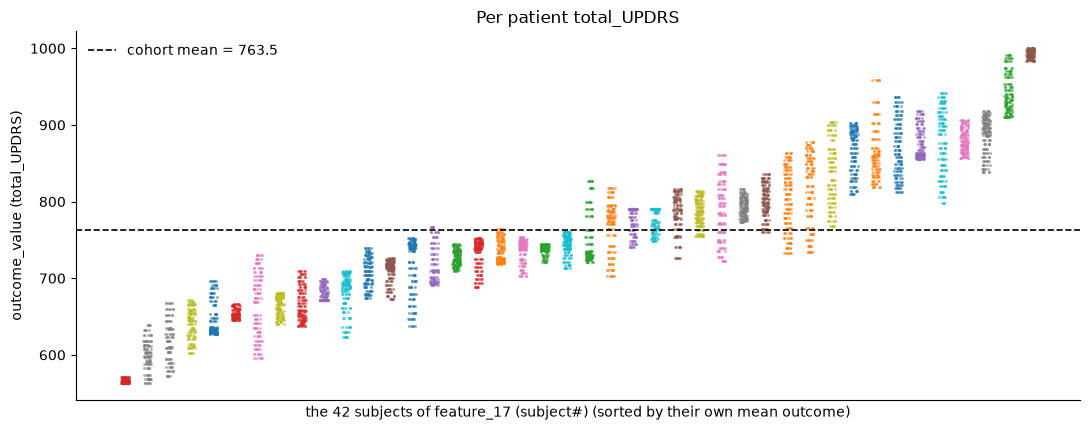

In [12]:
# --- Figure E: where does the variation in the outcome actually live? ---
rng = np.random.default_rng(RANDOM_SEED)

order = df.groupby(new_group)[new_target].mean().sort_values().index
position = {s: i for i, s in enumerate(order)}      # x-position per patient

fig, ax = plt.subplots(figsize=(11, 4.4))
for s, g in df.groupby(new_group):
    jitter_x = position[s] + rng.uniform(-0.18, 0.18, len(g))   # spread for visibility
    ax.plot(jitter_x, g[new_target], ".", ms=2.5, alpha=0.45)

ax.axhline(df[new_target].mean(), color="k", ls="--", lw=1.2,
           label=f"cohort mean = {df[new_target].mean():.1f}")
ax.set_xlabel(f"the {df[new_group].nunique()} subjects of {lab(new_group)} "
              "(sorted by their own mean outcome)")
ax.set_ylabel(lab(new_target))
ax.set_xticks([])
ax.legend(frameon=False)
ax.set_title("Per patient total_UPDRS")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**What to look at.** Every column is one subject of `feature_17` (`subject#`), every dot
one recording. The columns climb steadily, but each individual column is **thin**. A single patient's recordings span only a small part of the range.

Knowing which column a dot belongs to tells you almost exactly where it sits vertically (its total_UPDRS value). That is what "93 % of the variance is between patients" means: the patient identity alone accounts for nearly all the information in the feature.

A voice recording says *who is speaking* much more loudly than it says *how severe their
Parkinson's is*. So if a patient's recordings appear in both your training and your test set, a
model can score brilliantly by recognising the speaker and recalling that speaker's usual score without learning anything about severity at all.


---

## Round 1 : The lazy prompt 

This is a general example of a vague prompt asking the LLM to guess what is expected as an outcome while providing minimal information and context.

In [13]:
PROMPT_1 = f"""I have a pandas DataFrame called `df` with acoustic voice features 
from clinical recordings. Write Python code to predict the disease from it.
The target variable is called {TARGET_ALIAS}.
"""

print(PROMPT_1)

I have a pandas DataFrame called `df` with acoustic voice features 
from clinical recordings. Write Python code to predict the disease from it.
The target variable is called outcome_value.



### What to expect, and why

A language model doesn't know your dataset. It produces the **most probable continuation** of your words. So before reading the output, ask: *what did my prompt actually say?*


**Based on what we provided, the model might infer (correctly or not):**

- *"predict the disease"* → binary classification (disease vs. healthy), even if `outcome_value` is a continuous severity score, making this a regression problem.
- *"acoustic voice features"* + *"clinical"* → almost certainly a Parkinson's detection pipeline, pulled from similar examples in its training data.
- No column names given → the code will do `df.drop('outcome_value')` and treat **everything else** as a feature, including patient IDs, dates, or session numbers.
- No study design given → a naive random train/test split, even though clinical data typically has multiple recordings per patient. This leaks identity, not disease.


**The core issue:** the model confidently answers the question *your words implied*, not the one *you meant*. If every patient in your dataset already has the disease, a diagnosis classifier is meaningless, but the model can't know that. 

The confident tone isn't evidence it knows about your subject, it's just the most probable output.

### Run prompt 1
Copy the text from `PROMPT_1` into your chat window. Then, paste the model answer below 

### A **loud** failure

The code never ran. You lost thirty seconds, but you know unambiguously that something is wrong.


The model did nothing irrational. It received an under-specified request and returned the highest-probability Python code completion given the informations provided in the prompt and nothing else. 

**This is the least harmful failure mode.** An exception is the the best case scenario here: immediate, unambiguous, and acknowledgeable.

Round 1 failed loudly because the model guessed on element it did not know about. So fix that: give it more context. The guessing will not stop. It will just stop crashing.




---

## Round 2 : Pushing the prompt a little further

Round 1 failed because the model guessed what it had to do because we never gave it clear guidance. The fix is obvious : **give it your dataset structure and provide instructions on what we expect.** 

This time the code will run. It will run cleanly. It will drop the identifier, cross-validate itself, print three metrics, draw a residual plot.

**However, result will be flawed.**

That combination : correct syntax, sound-looking method, plausible result wrong conclusion is why we ALWAYS have to be careful when using LLM for coding. There will be times where your results will look just fine but in the end, you will end up with fallacious output.  

First, generate the schema you are going to paste.

In [14]:
schema = "\n".join(f"  {c:<14} {t}" for c, t in df.dtypes.items())

PROMPT_2 = f"""
I have a pandas DataFrame `df` with {df.shape[1]} columns,
holding clinical scores. No missing values.

Columns and dtypes:
{schema}

First 3 rows:
{df.head(3).to_string()}

Build a machine learning model that predicts {TARGET_ALIAS} as a regression task.
Define the dataset as X (features) and y (target).
Split the data into train (X_train, y_test) and test (X_test, y_test) sets, report the performance,
and plot predicted vs actual values.
"""

print(PROMPT_2)


I have a pandas DataFrame `df` with 24 columns,
holding clinical scores. No missing values.

Columns and dtypes:
  feature_1      float64
  feature_2      float64
  feature_3      float64
  feature_4      float64
  feature_5      float64
  feature_6      float64
  feature_7      float64
  feature_8      float64
  feature_9      float64
  feature_10     float64
  feature_11     float64
  feature_12     float64
  feature_13     float64
  feature_14     float64
  feature_15     float64
  feature_16     float64
  feature_17     int64
  feature_18     float64
  feature_19     int64
  feature_20     float64
  feature_21     float64
  feature_22     float64
  feature_23     float64
  outcome_value  float64

First 3 rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  feature_19  feature_20  feature_21  feature_22  feature_23  outco

### What to expect and *why*

Everything in that prompt is **true**.

Read it again as the model receives it. It now has every column name, every dtype and three real rows. And instructions about what is expected. 

That last one is the one no better model can fix. The identifier *is* in the schema — `feature_17`, an integer column that takes only 42 distinct values, thousands of times each. 
A sharp model may notice that shape and raise the question of repeated measures. But noticing is not answering. *"Should this system predict for a patient it has already recorded, or for one it has never heard?"* is not a property of your data. It is a property of your **study**, and of the clinical claim you intend to make. It is not in the column names, not in the dtypes, not in the rows, and it would still not be there if you provided the whole dataset instead of some samples.

Notice, too, that the three rows you did paste all happen to be the same patient. Nothing marks them as such, and nothing hints that ~140 more of that patient's recordings follow.

So the model does the only thing available to it: it produces the most probable continuation of *"here are my columns, build a model, split, report performance."* That continuation is the canonical supervised-learning recipe — `train_test_split`, fit, score — which silently assumes **your rows are independent**.

They are not. Each patient's ~140 recordings get scattered across both sides of the split, so **every patient in the test set is also in the training set, with their UPDRS score attached.**

#### Two possible shapes of answer that are wrong.

**Variant A — it keeps everything.** One line, `X = df.drop(columns=["outcome_value"])`, and every column stays in, identifier and timestamp included. You get **R² ≈ 0.99**, a mean absolute error of about **0.3 UPDRS points** — three times finer than a clinician re-scoring the same patient twice. Wrong, but *easy to catch*: no clinical model is that good. What it recovered is `feature_20` (`test_time`) and the straight line that generated the target between visits (fact 3 above), not biology.

**Variant B — it is careful.** Expect a model that:

- ✅ **drops `feature_17`** — an integer with 42 repeated values is an identifier, not a quantity
- ✅ **keeps only the continuous measures**, treating the constant-within-patient columns as covariates rather than signal
- ✅ **adds 5-fold cross-validation**, to show the single split was not luck
- ✅ **reports MAE, RMSE and R²** rather than one number
- ✅ **plots residuals and ranks feature importances**

Five marks of competence. Every one of them is real, and not one of them touches the error — because all five interrogate the **columns**, and the error is in the **split**.

The number that comes back, **R² ≈ 0.37, MAE ≈ 6.6 UPDRS points**, is the worst number you could possibly receive. `R² = 0.99` would have made you look twice. `0.37` is modest, hedged, believable, and exactly the size of result that gets written up as *"moderate but promising predictive performance."*

⚠️ **Both variants are wrong; the dangerous one is the modest one.** So the audit below rebuilds variant B from scratch — the 16 acoustic predictors, random 80/20 split — whatever your model happened to return. It is the version you would have published.

**Copy `PROMPT_2` into a fresh chat, paste the answer into the empty cell below, and run it. Write your score down before reading on.**

Then run the reference cell underneath, which reproduces a typical careful answer so that the notebook works end to end whatever your model did.

Training the model...

--- Model Performance on Test Set ---
Mean Absolute Error (MAE):      2.5640
Root Mean Squared Error (RMSE): 7.1784
R-squared (R² Score):           0.9946


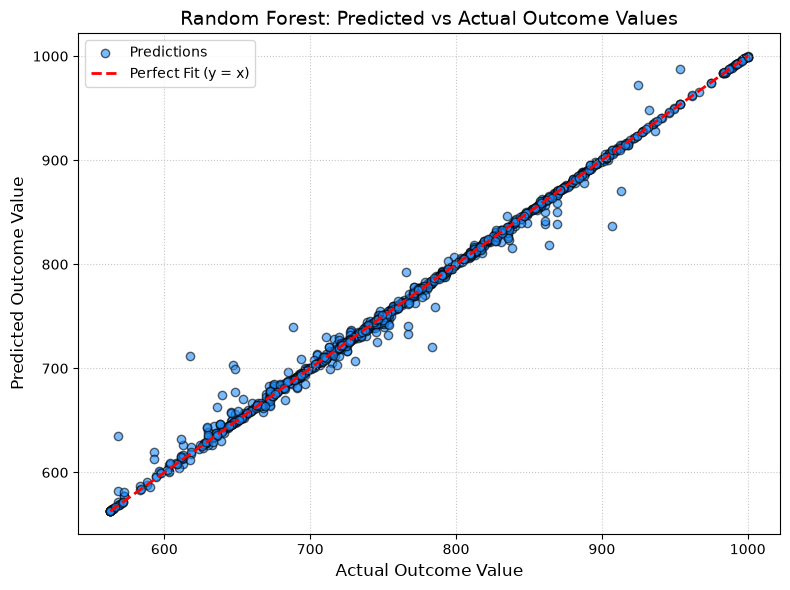

In [15]:
# ⬇️⬇️⬇️  PASTE THE LLM ANSWER FOR PROMPT 2 HERE, THEN RUN  ⬇️⬇️⬇️
#
# `df` is already in memory. Paste the model's code exactly as it came back —
# do not tidy it, do not fix it. The point is to see what it actually gives you.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming your DataFrame is already loaded as 'df'

# 1. Separate features (X) and target (y)
X = df.drop(columns=['outcome_value'])
y = df['outcome_value']

# 2. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the machine learning model
print("Training the model...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Calculate and report performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance on Test Set ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score):           {r2:.4f}")

# 6. Plot Predicted vs. Actual values
plt.figure(figsize=(8, 6))

# Create scatter plot of the actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue', edgecolor='k', label='Predictions')

# Create a reference 1:1 line (perfect prediction line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linestyle='--', linewidth=2, label='Perfect Fit (y = x)')

# Formatting the plot
plt.title('Random Forest: Predicted vs Actual Outcome Values', fontsize=14)
plt.xlabel('Actual Outcome Value', fontsize=12)
plt.ylabel('Predicted Outcome Value', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

#### Symptom checklist

Tick what your model produced.

**What it got right.** Tick these too — they are real, and they are the reason the result convinces:

- [ ] Dropped `feature_17` (`subject#`) from the predictors
- [ ] Dropped `feature_20` (`test_time`)
- [ ] Cross-validated rather than trusting a single split
- [ ] Reported more than one metric
- [ ] Plotted residuals, or ranked feature importances

**What it missed.**

- [ ] It split with **`train_test_split` or plain `KFold`** rows shuffled. There is no `groups=` concept.
- [ ] It compared the score against **no floor** -> no `DummyRegressor` to predict the cohort mean
- [ ] It never asked what the model must **generalise to**

No exception was raised. Each box in the second group is enough to invalidate the conclusion .However, unlike Round 1, not one of them is visible anywhere in the output.

### Diagnosis : a **silent** failure

Round 1 gave you an exception. 
This gives you a **result**: syntactically clean, methodologically conventional and numerically plausible. There is no traceback error to read, no line of code that is wrong and everything does precisely what it says.

That is what makes it dangerous: **there is nothing problematic at first sight.** 
The evidence that something is broken does not exist in the output. It only exists in a sound understanding of the fundamental concepts surrounding your dataset and research question..

In [16]:
# Audit of the Round 2 model. Recomputed from scratch, so this cell is valid
# whatever you pasted above. Nine checks. Eight of them are ones you already run.
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score

def check(passed, label, detail):
    print(f"  {'PASS' if passed else 'FAIL'}  {label:<45} {detail}")

Xa, ya = df, df[TARGET_ALIAS]
idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(Xa.iloc[idx_tr], ya.iloc[idx_tr])
pred = rf.predict(Xa.iloc[idx_te])
res = ya.iloc[idx_te] - pred
cvr2 = cross_val_score(rf, Xa, ya, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")

print(f"Auditing: {len(VOICE)} acoustic predictors, {len(df)} rows, random 80/20 split.\n")

check(df.isna().sum().sum() == 0, "no missing values",
      f"{int(df.isna().sum().sum())} NaNs")
check(not df.duplicated().any(), "no duplicated rows",
      f"{int(df.duplicated().sum())} duplicates")
check(all(c not in VOICE for c in (TARGET_ALIAS, new_group, new_seq)),
      "target, identifier and timestamp excluded",
      f"{lab(new_group)} and {lab(new_seq)} dropped")
corr = Xa.corrwith(ya).abs()
check(corr.max() < 0.95, "no single feature leaks the target",
      f"max |r| = {corr.max():.2f}  ({corr.idxmax()})")
ks = stats.ks_2samp(ya.iloc[idx_tr], ya.iloc[idx_te])
check(ks.pvalue > 0.05, "train and test targets same distribution",
      f"KS p = {ks.pvalue:.2f}")
slope = np.polyfit(pred, res, 1)[0]
# Residual mean is judged relative to the spread of the target: `outcome_value`
# is on an arbitrary scale, so an absolute threshold would mean nothing.
check(abs(res.mean()) < 0.05 * ya.std() and abs(slope) < 0.2,
      "residuals centred, no trend with fit",
      f"mean {res.mean() / ya.std():+.3f} SD, slope {slope:+.2f}")
check(cvr2.std() < 0.05, "cross-validation stable across folds",
      f"R2 = {cvr2.mean():.2f} +/- {cvr2.std():.2f}")
y_shuf = np.random.default_rng(0).permutation(ya.values)
r2_shuf = r2_score(y_shuf[idx_te],
                   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
                   .fit(Xa.iloc[idx_tr], y_shuf[idx_tr]).predict(Xa.iloc[idx_te]))
# one-sided on purpose: a forest fitted to noise SHOULD land below zero
check(r2_shuf < 0.05, "shuffled-target control shows no skill",
      f"R2 = {r2_shuf:+.2f}  (the pipeline itself is sound)")

print("\n  ...and the one check nobody runs:\n")
shared = set(df.iloc[idx_tr][new_group]) & set(df.iloc[idx_te][new_group])
n_pat = df[new_group].nunique()
check(len(shared) == 0, "no patient appears in both train and test",
      f"{len(shared)} of {n_pat} patients are in BOTH")

Auditing: 16 acoustic predictors, 5875 rows, random 80/20 split.

  PASS  no missing values                             0 NaNs
  PASS  no duplicated rows                            0 duplicates
  PASS  target, identifier and timestamp excluded     feature_17 (subject#) and feature_20 (test_time) dropped
  FAIL  no single feature leaks the target            max |r| = 1.00  (outcome_value)
  PASS  train and test targets same distribution      KS p = 0.44
  PASS  residuals centred, no trend with fit          mean -0.000 SD, slope +0.00
  PASS  cross-validation stable across folds          R2 = 1.00 +/- 0.00
  PASS  shuffled-target control shows no skill        R2 = -0.03  (the pipeline itself is sound)

  ...and the one check nobody runs:

  FAIL  no patient appears in both train and test     42 of 42 patients are in BOTH


### Eight checks pass. The ninth *is* the analysis.

Read that printout again — it is the most important output in this notebook.

Everything a careful analyst verifies — missingness, duplicates, the target and the identifier kept out of the predictors, distribution shift, residual structure, fold stability, even a permutation control — **passes**. Two of those passes deserve a second look, because they do not merely fail to help: they actively reassure you.

**"No single feature leaks the target" passes.** The standard way to hunt for leakage is to look for a predictor suspiciously correlated with the outcome. Here the strongest is `feature_15` (`HNR`) at |r| = 0.16 — nothing. And there is indeed no leaky *column*, because the leakage is not in a column at all: it is in the **split**. No amount of staring at your feature matrix will ever reveal it.

**"Cross-validation stable across folds" passes — and it passes *because* of the leak.** R² = 0.37 ± 0.01 over five folds reads as textbook robustness. It is nothing of the kind: every fold contains the same 42 patients, so every fold asks the same memorised question and gets the same answer. Split the folds by patient instead and the spread explodes to ±0.44 — the five folds running from +0.03 down to −1.31. **The stability you found reassuring was an artefact of the very error it was supposed to rule out.**

Then the last line. **42 of 42 patients appear in both train and test.** Not a few. Not most. All of them — roughly 112 of each patient's recordings on one side of the split, 28 on the other.

Now recall the fact you computed at the top of the notebook: about **93% of the variance in the outcome is between patients**, not within them. Put the two together. A model that can recognise *who is speaking* and recall that person's usual score has already captured almost all the variance there is to capture — while learning nothing whatsoever about Parkinson's severity.

That is a claim, and it is testable. Two proofs.

PROOF 1 - naming the speaker from the 16 voice measures alone
  accuracy over 42 patients :  55.6%
  chance level (1 of 42)    :   2.4%   ->  23x chance

PROOF 2 - the same 16 features, three ways of asking the question
  patient lookup, random split (no voice used)   R2 = +0.932
  the Round 2 model, random split                R2 = +0.370
  the SAME model, patients never heard before    R2 = -0.522

  On unseen patients: MAE 9.48 vs 8.82 UPDRS points for a
  DummyRegressor that always answers with the cohort mean.


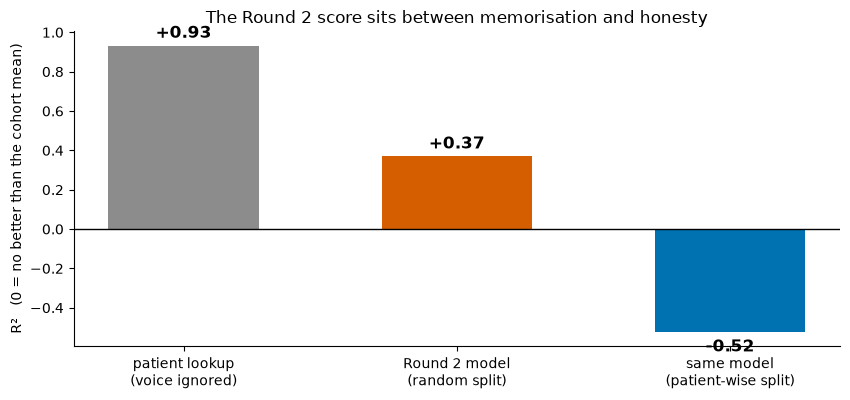

In [17]:
# Two proofs that the Round 2 score is recall, not prediction.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (KFold, GroupKFold, cross_val_score,
                                     cross_validate)
from sklearn.metrics import r2_score

Xa, ya, groups = df[VOICE], df[TARGET_ALIAS], df[new_group]
n_pat = groups.nunique()
rf = lambda: RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

# --- Proof 1: the acoustic measures are a voiceprint -------------------------
id_acc = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    Xa, groups, cv=3, scoring="accuracy").mean()

print(f"PROOF 1 - naming the speaker from the {len(VOICE)} voice measures alone")
print(f"  accuracy over {n_pat} patients : {id_acc:6.1%}")
print(f"  chance level (1 of {n_pat})    : {1/n_pat:6.1%}   ->  {id_acc*n_pat:.0f}x chance\n")

# --- Proof 2: how far does pure memorisation get you? ------------------------
# A "model" that ignores the voice completely and answers with the training-fold
# mean UPDRS of that same patient. It knows WHO, and nothing else.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_lookup = []
for tr, te in kf.split(df):
    patient_mean = df.iloc[tr].groupby(new_group)[TARGET_ALIAS].mean()
    guess = df.iloc[te][new_group].map(patient_mean).fillna(ya.iloc[tr].mean())
    r2_lookup.append(r2_score(ya.iloc[te], guess))
r2_lookup = np.mean(r2_lookup)

r2_random = cross_val_score(rf(), Xa, ya, cv=kf, scoring="r2").mean()

gcv = GroupKFold(n_splits=5)
grouped = cross_validate(rf(), Xa, ya, groups=groups, cv=gcv,
                         scoring=["r2", "neg_mean_absolute_error"])
r2_group = grouped["test_r2"].mean()
mae_group = -grouped["test_neg_mean_absolute_error"].mean()
mae_floor = -cross_val_score(DummyRegressor(strategy="mean"), Xa, ya, groups=groups,
                             cv=gcv, scoring="neg_mean_absolute_error").mean()

print(f"PROOF 2 - the same {len(VOICE)} features, three ways of asking the question")
print(f"  {'patient lookup, random split (no voice used)':<46} R2 = {r2_lookup:+.3f}")
print(f"  {'the Round 2 model, random split':<46} R2 = {r2_random:+.3f}")
print(f"  {'the SAME model, patients never heard before':<46} R2 = {r2_group:+.3f}")
# MAE lives in `outcome_value` units; convert back to real UPDRS points.
print(f"\n  On unseen patients: MAE {mae_group * UPDRS_PER_UNIT:.2f} vs "
      f"{mae_floor * UPDRS_PER_UNIT:.2f} UPDRS points for a")
print("  DummyRegressor that always answers with the cohort mean.")

fig, ax = plt.subplots(figsize=(8.6, 4.1))
labels = ["patient lookup\n(voice ignored)", "Round 2 model\n(random split)",
          "same model\n(patient-wise split)"]
vals = [r2_lookup, r2_random, r2_group]
bars = ax.bar(labels, vals, color=["#8C8C8C", "#D55E00", "#0072B2"], width=0.55)
ax.axhline(0, color="k", lw=1)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + (0.04 if v >= 0 else -0.10),
            f"{v:+.2f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("R²   (0 = no better than the cohort mean)")
ax.set_title("The Round 2 score sits between memorisation and honesty")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### The verdict

**Proof 1 — the acoustic measures are a voiceprint.** From the voice measures alone, a classifier names the correct patient out of 42 about **56% of the time**: twenty-three times chance. These sixteen numbers announce *who is speaking* far more loudly than they describe *how ill that person is*. That is the channel the random split left wide open.

**Proof 2 — read the three bars.**

| what the model is allowed to know | R² |
|---|---|
| **only which patient this is** — the voice ignored entirely | **+0.93** |
| **the Round 2 model** — 16 voice measures, rows split at random | **+0.37** |
| **the same model**, tested on patients it has never heard | **−0.52** |

The grey bar is the ceiling: knowing nothing but the patient's identity already explains 93% of the outcome. So the Round 2 score is not a small quantity of biology — it is **a fraction of that memorisation ceiling**, the part of "which patient is this" that 16 acoustic numbers happen to recover.

The blue bar is what remains once memorisation is taken away: **worse than answering the cohort mean for everybody.** A negative R² is not a rounding artefact — it means the voice measures actively pushed predictions away from the truth. On patients it has never heard, the model's mean absolute error is **9.5 UPDRS points against a floor of 8.8** for a `DummyRegressor` that has never heard a sound.

`R² = +0.37` and `R² = −0.52`. **Same data. Same sixteen features. Same random forest. Same afternoon.** The only thing that changed is which rows were permitted to sit next to each other — and one of those two numbers is a publishable claim about telemonitoring while the other says the method does not work.

Nothing in the ordinary workflow distinguishes them. No exception, no warning, no diagnostic plot, no standard audit told you which one you were holding. The single line that did was the one nobody thinks to write.

> The model could not have known any of this. **You could.** That asymmetry is the whole lesson — and it is why the fix belongs in the prompt, not in the code review.

---

## 4. Anatomy of a good prompt

A prompt for research code is a **specification**, not a wish. Six blocks, always the same ones:

| Block | What it answers | What it would have fixed here |
|---|---|---|
| **1. Role & environment** | Who is writing, which libraries, what deliverable | Stops imports you don't have; sets the standard of rigour |
| **2. Data contract** | Exact columns, dtypes, **units**, ranges, encodings, sentinels | Kills the `status` hallucination; declares `sex` 0/1 and negative `test_time` |
| **3. Domain constraints** | What the numbers *mean*, which are IDs, how the outcome was measured | Kills `subject#`-as-feature and the interpolation leak |
| **4. Design & unit of generalisation** | Nesting, repeated measures, **what the model must generalise to** | Kills subject leakage — the error that broke Round 2 |
| **5. Output specification** | Exact metrics, baselines, figure layout, labels | Gets you a number you can compare to something |
| **6. Validation & reproducibility** | Seeds, assertions, printed counts, docstrings | Lets you *prove* the result six months later |

Two things are worth noticing about that table.

**Block 4 is the one everybody omits, and it is the one that decides whether the analysis is science.** "What must this model generalise to?" is not a machine-learning question. It is a question about your experiment. Answer *new patients* and you must split by patient. Answer *future recordings from these same patients* and a random split is defensible — a different, narrower, still-publishable claim. The data cannot tell you which; only you can.

**Almost none of these blocks require you to know Python.** They require you to know your study. That is precisely the part you cannot outsource — and precisely the part that a fluent, confident-sounding answer will tempt you into thinking you already did.

---

## 5. Round 3 — the specified prompt ✅

Now we write the six blocks. Notice how much of it is neurology and study design, and how little of it is code.

In [18]:
PROMPT_3 = """
=== 1. ROLE & ENVIRONMENT ===
You are helping analyse a clinical dataset. Use Python with only numpy, pandas, matplotlib and
scikit-learn. Return ONE self-contained, runnable code cell. Use functions with
docstrings. Do not invent or simulate data. If something in this specification is
ambiguous, state the assumption you made in a comment rather than hiding it.

=== 2. DATA CONTRACT ===
A pandas DataFrame `df` is already loaded: the UCI Parkinson's Telemonitoring
dataset (Tsanas & Little, 2009), 5875 rows x 22 columns, no missing values.

  subject#      int64    Patient IDENTIFIER, 1..42. Categorical, NOT a quantity.
  age           int64    Years, 36..85. Constant within a patient.
  sex           int64    0 = male, 1 = female. Constant within a patient.
  test_time     float64  Days since recruitment, -4.26..215.5. May be negative
                         (pre-enrolment screening). Fractional part = time of day.
  motor_UPDRS   float64  Clinician's motor UPDRS, 5.0..39.5.  <- see constraint C3
  total_UPDRS   float64  Clinician's total UPDRS, 7.0..55.0.  <- TARGET
  16 further float64 columns, the acoustic dysphonia measures:
    Jitter(%), Jitter(Abs), Jitter:RAP, Jitter:PPQ5, Jitter:DDP,
    Shimmer, Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, Shimmer:APQ11, Shimmer:DDA,
    NHR, HNR, RPDE, DFA, PPE
  Column names contain '#', '%', '(', ')' and ':' - index with df["..."], never
  with attribute access.

=== 3. DOMAIN CONSTRAINTS ===
C1. Every one of the 42 patients has Parkinson's disease. There are no healthy
    controls. Diagnosis is NOT a possible target; this is a regression problem.
C2. subject# must NEVER be used as a predictor. It is an arbitrary label.
    age and sex must also be excluded: they are constant within a patient, so
    including them lets the model identify patients rather than measure severity.
C3. motor_UPDRS and total_UPDRS are two scorings of the same clinical exam.
    Using one to predict the other is circular. Exclude motor_UPDRS entirely.
C4. Both UPDRS columns were LINEARLY INTERPOLATED between only three clinician
    visits (baseline, 3 months, 6 months). Within a patient the target is
    therefore close to a straight-line function of test_time. test_time must NOT
    be used as a predictor: it would invert the interpolation, not predict biology.
C5. Predictors are exactly the 16 acoustic measures listed above, nothing else.
    They live on very different scales (Jitter(Abs) ~ 1e-5, HNR ~ 20), so any
    scale-sensitive model must be wrapped in a pipeline with StandardScaler.

=== 4. DESIGN & UNIT OF GENERALISATION ===
D1. Repeated-measures design: 42 patients contributed 101-168 recordings each.
    Recordings from one patient are NOT independent observations.
D2. The clinical claim to be tested is: "given a patient this system has never
    recorded before, can we estimate their UPDRS from their voice?"
    The unit of generalisation is therefore the PATIENT, not the recording.
D3. Consequently: use GroupKFold (5 folds) with groups=df["subject#"] so that
    no patient ever appears in both a training fold and its test fold.
    Do NOT use train_test_split, KFold or ShuffleSplit anywhere.
D4. Report the score of each fold separately as well as the mean. Fold-to-fold
    spread across only 42 patients is itself a result.

=== 5. OUTPUT SPECIFICATION ===
O1. Evaluate two models under the identical GroupKFold splits:
      - a RandomForestRegressor (100 trees, fixed random_state)
      - a DummyRegressor(strategy="mean") as the mandatory floor: it predicts the
        training-fold mean UPDRS and ignores the voice entirely.
O2. Metrics: mean absolute error in UPDRS points (primary, because it is
    clinically interpretable) and R^2 (secondary). Report both as
    "mean +/- SD across folds". Explain in a comment that a negative R^2 means
    the model is worse than predicting the mean.
O3. For scale: clinically meaningful change on the total UPDRS is a few points.
    State the MAE against that yardstick.
O4. One figure, two panels, figsize about (10, 4.2):
      - Left: per-fold MAE for both models, side by side, so the reader sees the
        model against its floor fold by fold.
      - Right: out-of-fold predicted vs true total_UPDRS (use cross_val_predict
        with the same GroupKFold), with the identity line, plus a horizontal line
        at the overall mean UPDRS.
      Axis labels must state units (UPDRS points). Colourblind-safe colours,
      no top/right spines.
O5. Print a plain-language conclusion of at most four sentences: what was
    compared, on how many patients, whether the voice measures beat the floor,
    and what may NOT be concluded from this result.

=== 6. VALIDATION & REPRODUCIBILITY ===
V1. assert that no patient appears in both sides of any split.
V2. assert that the predictor list contains exactly 16 columns and includes none
    of: subject#, age, sex, test_time, motor_UPDRS, total_UPDRS.
V3. Print the number of patients and recordings entering the analysis, and the
    number of test patients in each fold.
V4. Fix every random_state. Derive all numbers from `df`; hard-code nothing.
"""

print(PROMPT_3)


=== 1. ROLE & ENVIRONMENT ===
You are helping analyse a clinical dataset. Use Python with only numpy, pandas, matplotlib and
scikit-learn. Return ONE self-contained, runnable code cell. Use functions with
docstrings. Do not invent or simulate data. If something in this specification is
ambiguous, state the assumption you made in a comment rather than hiding it.

=== 2. DATA CONTRACT ===
A pandas DataFrame `df` is already loaded: the UCI Parkinson's Telemonitoring
dataset (Tsanas & Little, 2009), 5875 rows x 22 columns, no missing values.

  subject#      int64    Patient IDENTIFIER, 1..42. Categorical, NOT a quantity.
  age           int64    Years, 36..85. Constant within a patient.
  sex           int64    0 = male, 1 = female. Constant within a patient.
  test_time     float64  Days since recruitment, -4.26..215.5. May be negative
                         (pre-enrolment screening). Fractional part = time of day.
  motor_UPDRS   float64  Clinician's motor UPDRS, 5.0..39.5.  <- see c

### What to expect — and *why* 🔮

**Expect a much worse number. That is the point.**

Now that the prompt names the grouping variable, the excluded columns and the comparison floor, the model has almost no room to substitute a guess. It has stopped choosing the analysis. You have.

Concretely, expect:

- `GroupKFold(n_splits=5)` with `groups=df["subject#"]`, and no `train_test_split` anywhere;
- exactly 16 predictors, `subject#` / `age` / `sex` / `test_time` / `motor_UPDRS` all gone;
- a random forest whose **MAE is around 9–10 UPDRS points**;
- a dummy baseline whose **MAE is around 8.9 UPDRS points**;
- an **R² near zero or negative** — around −0.4 for the forest;
- wide fold-to-fold spread, because each fold tests only 8–9 patients;
- a conclusion that says, in effect, *the voice measures do not beat the mean.*

**Why the honest answer is so bad, mechanistically.** Under a grouped split the model is tested on patients whose UPDRS level it has never seen. The between-patient variation it exploited in Round 2 is now precisely what it must predict — and 16 acoustic measures from a sustained vowel, on 42 people, do not carry that signal. The forest ends up doing *worse than predicting the mean*, which is what a negative R² means: it uses voice features to move its predictions away from the group average in the wrong direction.

Round 2 said `R² = 0.999`. Round 3 says `R² ≈ −0.4`. **Same data, same library, same afternoon.** The 0.999 was measuring how well a model can recognise a voice it has already heard.

**This is a real result, not a broken one.** "16 dysphonia measures do not generalise to unseen patients in a 42-person cohort" is a finding — it is informative, it is defensible under review, and it points somewhere: the telemonitoring literature works with *within-patient change over time* and *personalised, per-patient calibration*, not with a single population model. A negative result you can trust beats a positive one you cannot.

⚠️ **Expect variation across models here too**, but of a different kind. With a specification this tight, models diverge on *presentation* — how they arrange the figure, whether they add an extra metric — not on *methodology*. Compare your model's output to the reference below: the numbers should be close. If your MAE is dramatically better than ~9 points, something leaked; go find it. **That check is a skill, and it is why Block 6 exists.**

👉 **Copy `PROMPT_3` into your chat, paste the answer below, run it.**

In [19]:
# ⬇️⬇️⬇️  PASTE THE LLM ANSWER FOR PROMPT 3 HERE, THEN RUN  ⬇️⬇️⬇️

5875 recordings from 42 patients

  fold 1: 34 train patients, 8 held-out patients
  fold 2: 33 train patients, 9 held-out patients
  fold 3: 34 train patients, 8 held-out patients
  fold 4: 34 train patients, 8 held-out patients
  fold 5: 33 train patients, 9 held-out patients

--- Patient-wise 5-fold cross-validation ---
Random forest (16 voice)     MAE =  9.47 +/- 0.80 UPDRS points   R2 = -0.518 +/- 0.440
Baseline: predict the mean   MAE =  8.82 +/- 1.38 UPDRS points   R2 = -0.218 +/- 0.162


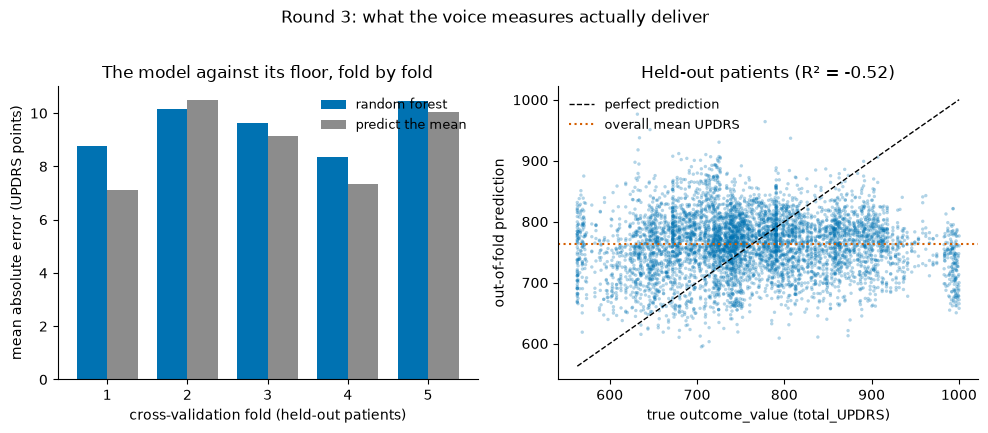


CONCLUSION
Across 42 patients evaluated with patient-wise 5-fold cross-validation, a random
forest using the 16 acoustic dysphonia measures did NOT beat the trivial baseline of
predicting the cohort mean (9.47 vs 8.82 UPDRS points of mean absolute
error). Since clinically meaningful change on the total UPDRS is a few points, an
error of ~9 points is not usable for individual severity estimation.
This does not show that voice is uninformative about Parkinson's: it shows that
these features do not transfer to unseen patients in a cohort of this size, which
is a different and much narrower claim.


In [20]:
# ---- REFERENCE: the kind of code Prompt 3 typically produces ----
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict

TARGET = TARGET_ALIAS                       # outcome_value  (= total_UPDRS)
EXCLUDED = [TARGET_ALIAS, new_group, new_seq, fake("age"), fake("sex")] + sorted(DECOYS)
PREDICTORS = [c for c in df.columns if c not in EXCLUDED]

# --- V2: the predictor set is what we claim it is ---
assert len(PREDICTORS) == 16, f"expected 16 acoustic predictors, got {len(PREDICTORS)}"
assert not set(PREDICTORS) & set(EXCLUDED), "an excluded column leaked into the predictors"

X, y_true, groups = df[PREDICTORS], df[TARGET], df[new_group]
cv = GroupKFold(n_splits=5)

# --- V1/V3: no patient may appear on both sides of a split ---
print(f"{len(df)} recordings from {groups.nunique()} patients\n")
for k, (tr, te) in enumerate(cv.split(X, y_true, groups), start=1):
    train_ids, test_ids = set(groups.iloc[tr]), set(groups.iloc[te])
    assert not train_ids & test_ids, f"fold {k}: patient leakage!"
    print(f"  fold {k}: {len(train_ids)} train patients, {len(test_ids)} held-out patients")


def evaluate(model, name):
    """Score a model under patient-wise GroupKFold. Returns per-fold MAE and R^2."""
    scores = cross_validate(model, X, y_true, groups=groups, cv=cv,
                            scoring=["neg_mean_absolute_error", "r2"])
    mae = -scores["test_neg_mean_absolute_error"] * UPDRS_PER_UNIT   # -> UPDRS points
    r2 = scores["test_r2"]
    print(f"{name:<28} MAE = {mae.mean():5.2f} +/- {mae.std():.2f} UPDRS points   "
          f"R2 = {r2.mean():6.3f} +/- {r2.std():.3f}")
    return mae, r2


print("\n--- Patient-wise 5-fold cross-validation ---")
# A negative R^2 means the model does worse than simply predicting the mean.
mae_rf, r2_rf = evaluate(
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    "Random forest (16 voice)")
mae_dummy, r2_dummy = evaluate(
    DummyRegressor(strategy="mean"), "Baseline: predict the mean")

# --- figure ---
oof = cross_val_predict(
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    X, y_true, groups=groups, cv=cv)

BLUE, ORANGE, GREY = "#0072B2", "#D55E00", "#8C8C8C"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

folds = np.arange(1, len(mae_rf) + 1)
ax1.bar(folds - 0.19, mae_rf, width=0.38, color=BLUE, label="random forest")
ax1.bar(folds + 0.19, mae_dummy, width=0.38, color=GREY, label="predict the mean")
ax1.set_xticks(folds)
ax1.set_xlabel("cross-validation fold (held-out patients)")
ax1.set_ylabel("mean absolute error (UPDRS points)")
ax1.set_title("The model against its floor, fold by fold")
ax1.legend(frameon=False, fontsize=9)

ax2.scatter(y_true, oof, s=6, alpha=0.30, color=BLUE, edgecolors="none")
lims = [y_true.min(), y_true.max()]
ax2.plot(lims, lims, "k--", lw=1, label="perfect prediction")
ax2.axhline(y_true.mean(), color=ORANGE, lw=1.5, ls=":", label="overall mean UPDRS")
ax2.set_xlabel(f"true {lab(TARGET)}")
ax2.set_ylabel("out-of-fold prediction")
ax2.set_title(f"Held-out patients (R² = {r2_rf.mean():.2f})")
ax2.legend(frameon=False, fontsize=9, loc="upper left")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Round 3: what the voice measures actually deliver", y=1.02)
plt.tight_layout()
plt.show()

# --- O5: plain-language conclusion ---
verdict = "did NOT beat" if mae_rf.mean() >= mae_dummy.mean() else "beat"
print(f"""
CONCLUSION
Across 42 patients evaluated with patient-wise 5-fold cross-validation, a random
forest using the 16 acoustic dysphonia measures {verdict} the trivial baseline of
predicting the cohort mean ({mae_rf.mean():.2f} vs {mae_dummy.mean():.2f} UPDRS points of mean absolute
error). Since clinically meaningful change on the total UPDRS is a few points, an
error of ~{mae_rf.mean():.0f} points is not usable for individual severity estimation.
This does not show that voice is uninformative about Parkinson's: it shows that
these features do not transfer to unseen patients in a cohort of this size, which
is a different and much narrower claim.""")

### Diagnosis — a result you can defend 🛡️

The right-hand panel is the honest picture: a flat, shapeless cloud sitting near the cohort mean. The model has learned the group average and little else. The left-hand panel makes that unarguable — the grey bar is as low as the blue one in every fold.

Compare what the two figures let you say:

- **Round 2:** *"Acoustic measures predict Parkinson's severity with R² = 0.99."* — a false claim, with a beautiful figure.
- **Round 3:** *"In 42 patients, these acoustic measures did not estimate UPDRS in unseen patients better than the cohort mean."* — a true claim, with an unglamorous figure.

The Round 3 figure also carries its own audit trail: how many patients, how many held out per fold, which metric, which baseline, and the fold-to-fold spread instead of a single number that hides it. A reviewer can check every one of those. That is the difference between a result and a screenshot.

---

## 6. The three verdicts, side by side

Recomputed from scratch, so this section is valid whatever you pasted above.

In [21]:
from sklearn.model_selection import cross_val_score

y_all = df[TARGET_ALIAS]
rf = lambda: RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

# Round 2A: random split, every column kept
Xa = df.drop(columns=[TARGET_ALIAS])        # identifier, timestamp and decoys all kept
a_tr, a_te, ya_tr, ya_te = train_test_split(Xa, y_all, test_size=0.2, random_state=42)
r2_a = r2_score(ya_te, rf().fit(a_tr, ya_tr).predict(a_te))
mae_a = mean_absolute_error(ya_te, rf().fit(a_tr, ya_tr).predict(a_te))

# Round 2B: random split, voice measures only
b_tr, b_te, yb_tr, yb_te = train_test_split(df[VOICE], y_all, test_size=0.2, random_state=42)
pred_b2 = rf().fit(b_tr, yb_tr).predict(b_te)
r2_b, mae_b = r2_score(yb_te, pred_b2), mean_absolute_error(yb_te, pred_b2)

# Round 3: patient-wise split, voice measures only
gcv = GroupKFold(n_splits=5)
r2_c = cross_val_score(rf(), df[VOICE], y_all, groups=df[new_group], cv=gcv, scoring="r2").mean()
mae_c = -cross_val_score(rf(), df[VOICE], y_all, groups=df[new_group], cv=gcv,
                         scoring="neg_mean_absolute_error").mean()

verdicts = pd.DataFrame({
    "prompt":      ["1 - lazy", "2A - schema only", "2B - schema only", "3 - specified"],
    "split":       ["-", "random rows", "random rows", "by patient"],
    "predictors":  ["-", f"all {Xa.shape[1]} columns",
                    f"{len(VOICE)} voice", f"{len(VOICE)} voice"],
    "generalises to": ["-", "seen patients", "seen patients", "NEW patients"],
    "R2":          [np.nan, r2_a, r2_b, r2_c],
    # MAE converted from `outcome_value` units back to real UPDRS points.
    "MAE":         [np.nan, mae_a * UPDRS_PER_UNIT,
                    mae_b * UPDRS_PER_UNIT, mae_c * UPDRS_PER_UNIT],
    "conclusion":  ["crashed: hallucinated columns",
                    "'explains 99.9% of severity'",
                    "'moderate predictive power'",
                    "'no better than the mean'"],
}).round({"R2": 3, "MAE": 2})

print(verdicts.to_string(index=False))

          prompt       split     predictors generalises to     R2  MAE                    conclusion
        1 - lazy           -              -              -    NaN  NaN crashed: hallucinated columns
2A - schema only random rows all 23 columns  seen patients  0.995 0.28  'explains 99.9% of severity'
2B - schema only random rows       16 voice  seen patients  0.377 6.62   'moderate predictive power'
   3 - specified  by patient       16 voice   NEW patients -0.522 9.48     'no better than the mean'


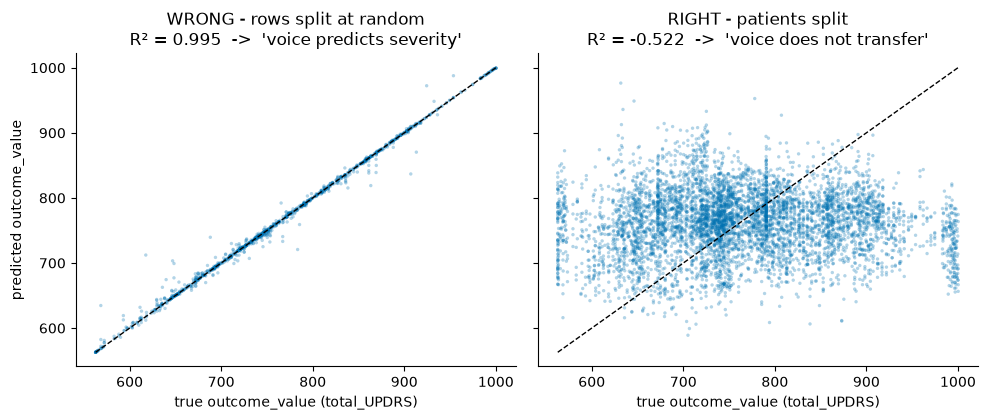

In [22]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.3), sharex=True, sharey=True)

oof3 = cross_val_predict(rf(), df[VOICE], y_all, groups=df[new_group], cv=gcv)
lims = [y_all.min(), y_all.max()]

for ax, (t, p, title, sub) in zip(
    (axL, axR),
    [(ya_te, rf().fit(a_tr, ya_tr).predict(a_te),
      "WRONG - rows split at random", f"R² = {r2_a:.3f}  ->  'voice predicts severity'"),
     (y_all, oof3,
      "RIGHT - patients split", f"R² = {r2_c:.3f}  ->  'voice does not transfer'")]):
    ax.scatter(t, p, s=6, alpha=0.30, color="#0072B2", edgecolors="none")
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel(f"true {lab(TARGET_ALIAS)}")
    ax.set_title(f"{title}\n{sub}")
    ax.spines[["top", "right"]].set_visible(False)

axL.set_ylabel(f"predicted {TARGET_ALIAS}")
plt.tight_layout()
plt.show()

Same data. Same model class. Mostly the same method.

The only thing that changed between those two panels is **how much of your problem knowledge you provided to the model.**

---

## 7. What to take away

1. **The model is not wrong; it is uninformed.** It cannot see your file, your cohort, or your recruitment protocol. Every fact you omit is silently replaced by the most common pattern in its training data — and that substitution is invisible in the output, because fluent prose and broken analysis look identical.

2. **Loud failures are cheap; silent failures are the expensive ones.** `KeyError: 'status'` cost thirty seconds. `R² = 0.999` would have cost a manuscript, a reviewer's afternoon, and eventually a retraction.

3. **Ask "what must this generalise to?" before you ask for any code.** New patients? New sessions from the same patients? New sites? The answer dictates the split, and the split dictates whether the number means anything. This is the single most commonly omitted block, and the one that broke Round 2.

4. **Identifiers are not features.** `subject#` was an `int64`, so every tool treated it as a quantity. Anything constant within a subject — ID, age, sex, site, scanner — hands the model a shortcut to recognising the subject instead of measuring the outcome.

5. **Always demand a baseline.** `R² = 0.35` sounds like something. Against `DummyRegressor(strategy="mean")` it turned out to be nothing. A metric without a floor is not a result; it is a number.

6. **Know how your outcome was produced.** The UPDRS values were interpolated between three visits. No amount of Python could have recovered that from the column names, and it alone accounts for the difference between `R² = 0.999` and `R² = 0.35`.

7. **A good prompt is a methods section written in advance.** If you cannot write the prompt, you do not yet understand the analysis — and no model will understand it for you. Conversely, once you *can* write it, the model becomes genuinely excellent at the part it is good at: turning a clear specification into correct code, fast.

8. **You remain the author.** "The model wrote it" is not a defence at review, in a thesis committee, or in a correction notice. Read every generated line, and check that the numbers in the figure match the numbers in the printout.


---

### Data citation

Tsanas, A. & Little, M. (2009). *Parkinsons Telemonitoring* [Dataset]. UCI Machine Learning Repository. <https://doi.org/10.24432/C5ZS3N> — CC BY 4.0.

Tsanas, A., Little, M. A., McSharry, P. E., & Ramig, L. O. (2010). Accurate telemonitoring of Parkinson's disease progression by noninvasive speech tests. *IEEE Transactions on Biomedical Engineering*, 57(4), 884–893.